# Setup

In [1]:
# Import Libraries
import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
# Connect Google Drive to upload images
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# Paths to your images from Google Drive
image1_path = '/content/drive/MyDrive/ECE457_project/images/img1.jpg'
image2_path = '/content/drive/MyDrive/ECE457_project/images/img2.jpg'
image3_path = '/content/drive/MyDrive/ECE457_project/images/img3.jpg'

image_paths = [image1_path, image2_path, image3_path]

In [4]:
# Alternative: upload images without connecting the Google Drive
'''
from google.colab import files
# Open file upload dialog
uploaded = files.upload()
'''

'\nfrom google.colab import files\n# Open file upload dialog\nuploaded = files.upload()\n'

# LOAD & DISPLAY IMAGES

In [5]:
def load_images(paths):
    # Load the images in BGR format and convert them to RGB for display with Matplotlib
    images = [cv2.imread(path, cv2.IMREAD_COLOR) for path in paths]
    images_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in images]
    return images_rgb

# Load images
images_mountains = load_images(image_paths)

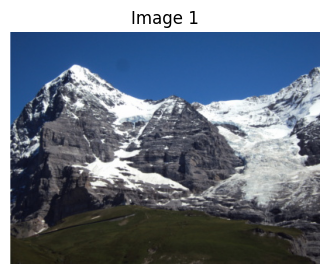

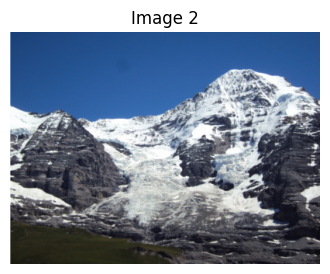

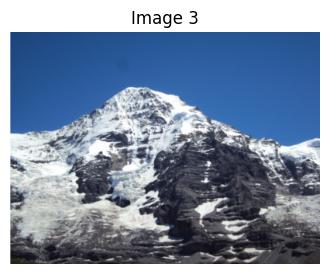

In [6]:
def display_images(images):
    # Display each image using Matplotlib
    for i, img in enumerate(images):
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.title(f'Image {i+1}')
        plt.axis('off')  # Hide axis labels
        plt.show()

# Display the images
display_images(images_mountains)

# SIFT feature extraction

## Implement the SIFT feature extraction to detect keypoints and compute descriptors.

In [7]:
def detect_sift_features(images):
    sift = cv2.SIFT_create()
    keypoints, descriptors = [], []
    for img in images:
        kp, des = sift.detectAndCompute(img, None)
        keypoints.append(kp)
        descriptors.append(des)
    return keypoints, descriptors

# Detect features
keypoints, descriptors = detect_sift_features(images_mountains)

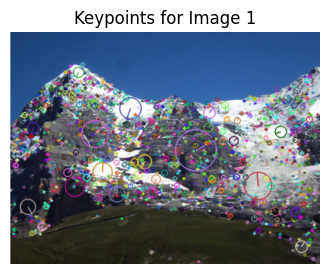

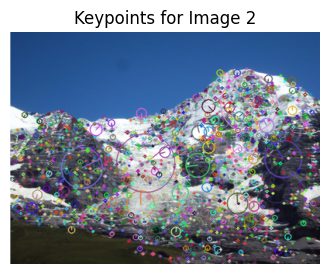

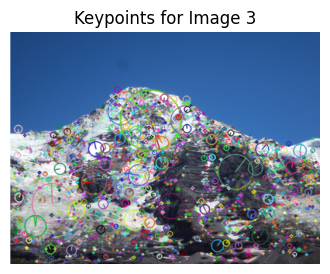

In [8]:
def draw_keypoints(images, keypoints):
    for i, (img, kp) in enumerate(zip(images, keypoints)):
        img_with_kp = cv2.drawKeypoints(img, kp, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
        plt.figure(figsize=(4, 4))
        plt.imshow(img_with_kp, cmap='gray')
        plt.title(f'Keypoints for Image {i+1}')
        plt.axis('off')
    plt.show()

# Display keypoints
draw_keypoints(images_mountains, keypoints)

## Match keypoints between overlapping images.

In [9]:
def match_keypoints(des1, des2):
    bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)  # Sort by distance
    return matches


# Match keypoints pairwise
matches12 = match_keypoints(descriptors[0], descriptors[1])
matches23 = match_keypoints(descriptors[1], descriptors[2])

## Display matched keypoints using OpenCV.



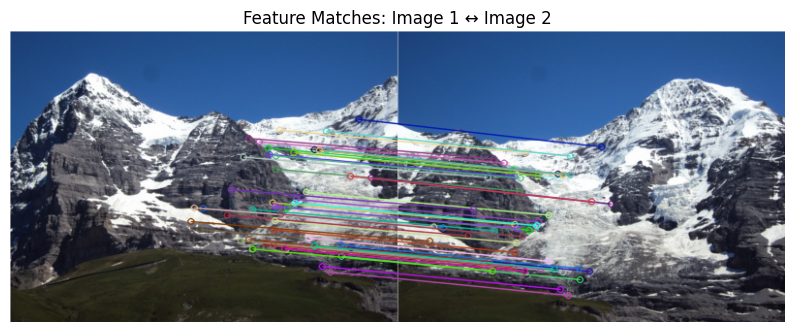

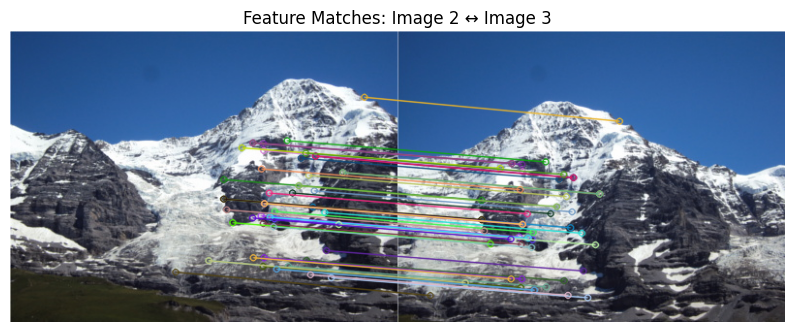

In [10]:
def draw_matches(img1, kp1, img2, kp2, matches, img_index1, img_index2, num_matches=50):
    match_img = cv2.drawMatches(img1, kp1, img2, kp2, matches[:num_matches], None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

    plt.figure(figsize=(10, 5))
    plt.imshow(match_img, cmap='gray')
    plt.title(f'Feature Matches: Image {img_index1} ↔ Image {img_index2}')
    plt.axis('off')
    plt.show()

# Display matches with image indices (starting from 1)
draw_matches(images_mountains[0], keypoints[0], images_mountains[1], keypoints[1], matches12, 1, 2)
draw_matches(images_mountains[1], keypoints[1], images_mountains[2], keypoints[2], matches23, 2, 3)

In [11]:
def draw_inlier_outlier_matches(img1, kp1, img2, kp2, inliers, outliers):
    #  Draw inliers (green) and outliers (red)
    img_inliers = cv2.drawMatches(img1, kp1, img2, kp2, inliers, None, matchColor=(0,255,0), flags=2)
    img_outliers = cv2.drawMatches(img1, kp1, img2, kp2, outliers, None, matchColor=(255,0,0), flags=2)

    # Add text to the images showing the number of inliers and outliers
    inlier_text = f"Inliers: {len(inliers)}"
    outlier_text = f"Outliers: {len(outliers)}"

    # Choose font and position for text
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 1
    color = (255, 255, 255)  # White text
    thickness = 2

    # Place text at the bottom of each image
    img_inliers = cv2.putText(img_inliers, inlier_text, (10, img_inliers.shape[0] - 10), font, font_scale, color, thickness)
    img_outliers = cv2.putText(img_outliers, outlier_text, (10, img_outliers.shape[0] - 10), font, font_scale, color, thickness)

    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(img_inliers)
    plt.title("Inliers (Green)")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(img_outliers)
    plt.title("Outliers (Red)")
    plt.axis("off")

    plt.show()

# Display inliers and outliers
#draw_inlier_outlier_matches(images_mountains[0], keypoints[0], images_mountains[1], keypoints[1], inliers12, outliers12) # Fixed: Using inliers12 and outliers12
#draw_inlier_outlier_matches(images_mountains[1], keypoints[1], images_mountains[2], keypoints[2], inliers23, outliers23)

Custom RANSAC: Number of inliers = 515
OpenCV RANSAC: Number of inliers = 515
Custom RANSAC: Number of inliers for image 1 ↔ 2 = 515
OpenCV RANSAC: Number of inliers for image 1 ↔ 2 = 515
Custom RANSAC: Number of inliers for image 2 ↔ 3 = 687
OpenCV RANSAC: Number of inliers for image 2 ↔ 3 = 687


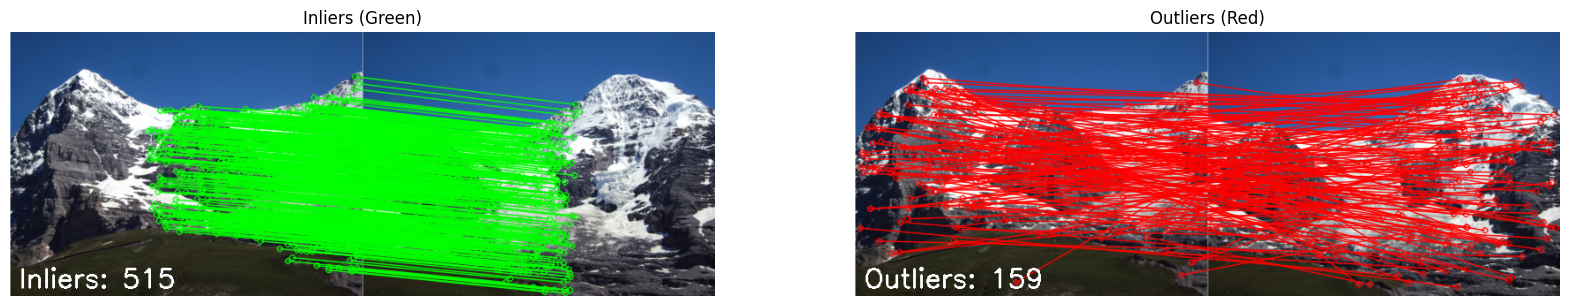

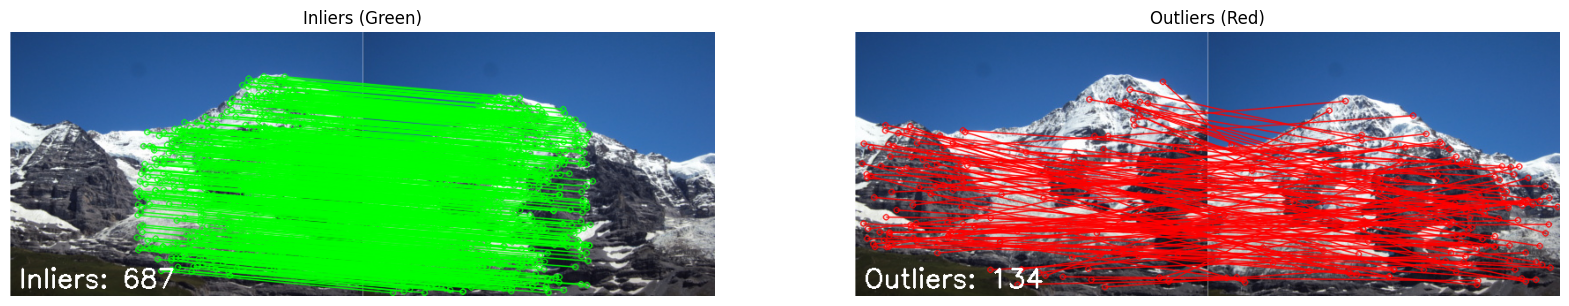

In [12]:
def compute_homography(pts1, pts2):
    """
    Compute the homography matrix from pts1 to pts2 using the Direct Linear Transform (DLT) method.
    pts1 and pts2 should be numpy arrays of shape (N, 2) containing matching (x, y) coordinates.
    """
    N = pts1.shape[0]
    A = []
    for i in range(N):
        x, y = pts1[i]
        xp, yp = pts2[i]
        # Two rows per correspondence
        A.append([-x, -y, -1, 0, 0, 0, x * xp, y * xp, xp])
        A.append([0, 0, 0, -x, -y, -1, x * yp, y * yp, yp])
    A = np.array(A)

    # Solve A * h = 0 using SVD; h is the flattened homography matrix
    U, S, Vt = np.linalg.svd(A)
    h = Vt[-1]  # last row of V^T corresponds to the smallest singular value
    H = h.reshape(3, 3)

    # Normalize to enforce the scale constraint (H[2,2] = 1)
    H = H / H[2, 2]
    return H

def ransac_homography(matches, kp1, kp2, threshold=5, iterations=100):
    """
    Implement RANSAC to estimate the homography matrix.
    - matches: list of DMatch objects between two images.
    - kp1, kp2: keypoints for image1 and image2 respectively.
    - threshold: reprojection error threshold in pixels.
    - iterations: number of RANSAC iterations.

    Returns:
        best_H: the homography matrix computed from all inliers.
        inlier_matches: list of matches considered inliers.
        outlier_matches: list of matches considered outliers.
    """
    num_matches = len(matches)
    best_inlier_mask = None
    max_inliers_count = 0
    best_H = None

    # Precompute point coordinates for all matches
    pts1 = np.array([kp1[m.queryIdx].pt for m in matches])
    pts2 = np.array([kp2[m.trainIdx].pt for m in matches])

    for _ in range(iterations):
        # Randomly select 4 unique matches
        indices = random.sample(range(num_matches), 4)
        pts1_sample = pts1[indices]
        pts2_sample = pts2[indices]

        try:
            H_candidate = compute_homography(pts1_sample, pts2_sample)
        except np.linalg.LinAlgError:
            continue

        # Convert pts1 to homogeneous coordinates
        pts1_homog = np.hstack([pts1, np.ones((num_matches, 1))])  # shape (N,3)
        projected_pts2 = (H_candidate @ pts1_homog.T).T  # shape (N,3)
        projected_pts2 = projected_pts2 / projected_pts2[:, 2][:, np.newaxis]  # normalize

        # Compute Euclidean distance between projected and actual pts2
        errors = np.linalg.norm(pts2 - projected_pts2[:, :2], axis=1)
        inlier_mask = errors < threshold
        inliers_count = np.sum(inlier_mask)

        # Update the best model if the current one has more inliers
        if inliers_count > max_inliers_count:
            max_inliers_count = inliers_count
            best_inlier_mask = inlier_mask.copy()
            best_H = H_candidate

    # Recompute homography using all inlier matches from the best model
    if max_inliers_count >= 4:
        pts1_inliers = pts1[best_inlier_mask]
        pts2_inliers = pts2[best_inlier_mask]
        best_H = compute_homography(pts1_inliers, pts2_inliers)
    else:
        print("Not enough inliers found!")

    # Separate the matches into inliers and outliers
    inlier_matches = [matches[i] for i in range(num_matches) if best_inlier_mask[i]]
    outlier_matches = [matches[i] for i in range(num_matches) if not best_inlier_mask[i]]

    return best_H, inlier_matches, outlier_matches

H_ransac, inliers12, outliers12 = ransac_homography(matches12, keypoints[0], keypoints[1],
                                                     threshold=5, iterations=100)
print(f"Custom RANSAC: Number of inliers = {len(inliers12)}")


### Compare with OpenCV's built-in findHomography method
pts1_cv = np.array([keypoints[0][m.queryIdx].pt for m in matches12])
pts2_cv = np.array([keypoints[1][m.trainIdx].pt for m in matches12])
H_cv, mask = cv2.findHomography(pts1_cv, pts2_cv, cv2.RANSAC, 5.0)
inlier_mask_cv = mask.ravel().astype(bool)
inlier_matches_cv = [matches12[i] for i in range(len(matches12)) if inlier_mask_cv[i]]
print(f"OpenCV RANSAC: Number of inliers = {np.sum(mask)}")

# Compute homography using RANSAC for image 1 ↔ 2
H_ransac_12, inliers12, outliers12 = ransac_homography(matches12, keypoints[0], keypoints[1],
                                                        threshold=5, iterations=100)
print(f"Custom RANSAC: Number of inliers for image 1 ↔ 2 = {len(inliers12)}")

# Compute homography using OpenCV for image 1 ↔ 2
pts1_cv_12 = np.array([keypoints[0][m.queryIdx].pt for m in matches12])
pts2_cv_12 = np.array([keypoints[1][m.trainIdx].pt for m in matches12])
H_cv_12, mask_12 = cv2.findHomography(pts1_cv_12, pts2_cv_12, cv2.RANSAC, 5.0)
inlier_mask_cv_12 = mask_12.ravel().astype(bool)
inlier_matches_cv_12 = [matches12[i] for i in range(len(matches12)) if inlier_mask_cv_12[i]]
print(f"OpenCV RANSAC: Number of inliers for image 1 ↔ 2 = {np.sum(mask_12)}")

# Compute homography using RANSAC for image 2 ↔ 3
H_ransac_23, inliers23, outliers23 = ransac_homography(matches23, keypoints[1], keypoints[2],
                                                        threshold=5, iterations=100)
print(f"Custom RANSAC: Number of inliers for image 2 ↔ 3 = {len(inliers23)}")

# Compute homography using OpenCV for image 2 ↔ 3
pts1_cv_23 = np.array([keypoints[1][m.queryIdx].pt for m in matches23])
pts2_cv_23 = np.array([keypoints[2][m.trainIdx].pt for m in matches23])
H_cv_23, mask_23 = cv2.findHomography(pts1_cv_23, pts2_cv_23, cv2.RANSAC, 5.0)
inlier_mask_cv_23 = mask_23.ravel().astype(bool)
inlier_matches_cv_23 = [matches23[i] for i in range(len(matches23)) if inlier_mask_cv_23[i]]
print(f"OpenCV RANSAC: Number of inliers for image 2 ↔ 3 = {np.sum(mask_23)}")

# Visualize inliers and outliers for image 1 ↔ 2
draw_inlier_outlier_matches(images_mountains[0], keypoints[0],
                            images_mountains[1], keypoints[1],
                            inliers12, outliers12)

# Visualize inliers and outliers for image 2 ↔ 3
draw_inlier_outlier_matches(images_mountains[1], keypoints[1],
                            images_mountains[2], keypoints[2],
                            inliers23, outliers23)



## Warp and Stitch Images Incrementally


In [32]:
# Warp and Stitch Images Incrementally
def warp_images(base_img, new_img, H):
    # Ensure images are in BGR before warping
    base_img = cv2.cvtColor(base_img, cv2.COLOR_RGB2BGR)
    new_img = cv2.cvtColor(new_img, cv2.COLOR_RGB2BGR)

    # Ensure homography matrix has float32 data type
    H = H.astype(np.float32)

    h_base, w_base = base_img.shape[:2]
    h_new, w_new = new_img.shape[:2]

    # Transform the corners of new_img
    corners_new = np.float32([[0, 0], [0, h_new], [w_new, h_new], [w_new, 0]]).reshape(-1, 1, 2)
    transformed_corners_new = cv2.perspectiveTransform(corners_new, H)

    # Compute the bounding box of the transformed image
    all_corners = np.concatenate((transformed_corners_new, np.float32([[0, 0], [0, h_base], [w_base, h_base], [w_base, 0]]).reshape(-1, 1, 2)), axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    # Compute translation to shift the images into the final canvas
    translation_dist = [-x_min, -y_min]
    translation_matrix = np.array([[1, 0, translation_dist[0]], [0, 1, translation_dist[1]], [0, 0, 1]])

    # Warp new image to fit in the panorama
    warped_new = cv2.warpPerspective(new_img, translation_matrix @ H, (x_max - x_min, y_max - y_min))

    return base_img, warped_new, translation_dist

## Blending

In [33]:
# 1. Simple Averaging Blend
def simple_averaging(base_img, warped_new, translation_dist):
    h_base, w_base = base_img.shape[:2]
    stitched = warped_new.copy()

    stitched[translation_dist[1]:h_base+translation_dist[1], translation_dist[0]:w_base+translation_dist[0]] = (
        0.5 * base_img + 0.5 * stitched[translation_dist[1]:h_base+translation_dist[1], translation_dist[0]:w_base+translation_dist[0]]
    ).astype(np.uint8)

    return stitched

In [34]:
# 2. Linear Feather Blending
def linear_blending(base_img, warped_new, translation_dist):
    h_base, w_base = base_img.shape[:2]
    stitched = warped_new.copy()

    mask = np.zeros_like(base_img, dtype=np.float32)
    mask[:, :w_base] = np.tile(np.linspace(1, 0, w_base, dtype=np.float32), (h_base, 1))[:, :, None]

    mask_blurred = cv2.GaussianBlur(mask, (5, 5), 5)
    stitched[translation_dist[1]:h_base+translation_dist[1], translation_dist[0]:w_base+translation_dist[0]] = (
        base_img * mask_blurred + stitched[translation_dist[1]:h_base+translation_dist[1], translation_dist[0]:w_base+translation_dist[0]] * (1 - mask_blurred)
    ).astype(np.uint8)

    return stitched

In [35]:
def laplacian_blending(base_img, warped_new, translation_dist, levels=4):
    h_base, w_base = base_img.shape[:2]
    stitched = warped_new.copy()

    mask = np.ones_like(base_img, dtype=np.float32)
    mask[:, :w_base] = np.tile(np.linspace(1, 0, w_base, dtype=np.float32), (h_base, 1))[:, :, None]
    mask = cv2.GaussianBlur(mask, (5, 5), 5)

    gp_base = [base_img]
    gp_warped = [stitched[translation_dist[1]:h_base+translation_dist[1], translation_dist[0]:w_base+translation_dist[0]]]
    gp_mask = [mask]

    for _ in range(levels):
        base_img = cv2.pyrDown(base_img)
        warped_new = cv2.pyrDown(warped_new)
        mask = cv2.pyrDown(mask)
        gp_base.append(base_img)
        gp_warped.append(warped_new)
        gp_mask.append(mask)

    lp_base = [gp_base[-1]]
    lp_warped = [gp_warped[-1]]

    for i in range(levels - 1, 0, -1):
        upsampled_base = cv2.pyrUp(gp_base[i])
        upsampled_base = cv2.resize(upsampled_base, (gp_base[i - 1].shape[1], gp_base[i - 1].shape[0]))
        laplacian_base = cv2.subtract(gp_base[i - 1], upsampled_base)

        upsampled_warped = cv2.pyrUp(gp_warped[i])
        upsampled_warped = cv2.resize(upsampled_warped, (gp_warped[i - 1].shape[1], gp_warped[i - 1].shape[0]))
        laplacian_warped = cv2.subtract(gp_warped[i - 1], upsampled_warped)

        lp_base.append(laplacian_base)
        lp_warped.append(laplacian_warped)

    blended_pyramid = []
    for i in range(len(lp_base)):
        l1 = cv2.resize(lp_base[i], (gp_mask[i].shape[1], gp_mask[i].shape[0]))
        l2 = cv2.resize(lp_warped[i], (gp_mask[i].shape[1], gp_mask[i].shape[0]))

        blended_level = l1 * gp_mask[i] + l2 * (1 - gp_mask[i])
        blended_pyramid.append(blended_level)

    blended = blended_pyramid[0]
    for i in range(1, levels):
        blended = cv2.pyrUp(blended)
        blended = cv2.resize(blended, (blended_pyramid[i].shape[1], blended_pyramid[i].shape[0]))
        blended = cv2.add(blended, blended_pyramid[i])

    # Ensure blended is resized to match base_img dimensions before inserting
    blended = cv2.resize(blended, (w_base, h_base))

    # Assign the blended region to the stitched image
    stitched[translation_dist[1]:h_base+translation_dist[1], translation_dist[0]:w_base+translation_dist[0]] = blended

    return stitched


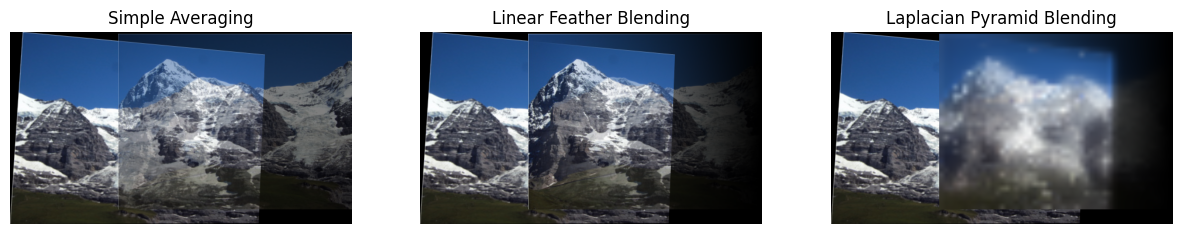

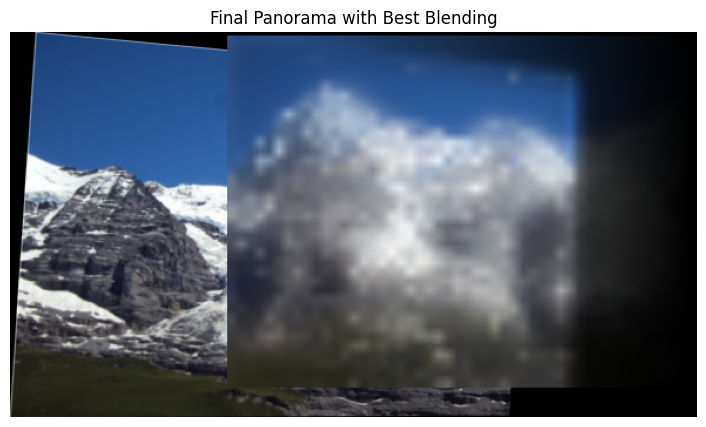

In [36]:
# Display Results
# Perform image warping and blending for each method
base_img_12, warped_img_12, translation_dist_12 = warp_images(images_mountains[0], images_mountains[1], H_ransac_12)

stitched_12_avg = simple_averaging(base_img_12, warped_img_12, translation_dist_12)
stitched_12_linear = linear_blending(base_img_12, warped_img_12, translation_dist_12)
stitched_12_laplacian = laplacian_blending(base_img_12, warped_img_12, translation_dist_12)  # This line was missing

# Choose one of the blending methods for the final panorama
final_panorama = stitched_12_laplacian  # or stitched_12_avg or stitched_12_linear

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(stitched_12_avg, cv2.COLOR_BGR2RGB))
plt.title("Simple Averaging")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(stitched_12_linear, cv2.COLOR_BGR2RGB))
plt.title("Linear Feather Blending")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(stitched_12_laplacian, cv2.COLOR_BGR2RGB)) # Now 'stitched_12_laplacian' is defined
plt.title("Laplacian Pyramid Blending")
plt.axis("off")

plt.show()
# Display Final Panorama
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(final_panorama, cv2.COLOR_BGR2RGB))
plt.title("Final Panorama with Best Blending")
plt.axis("off")
plt.show()

# Image Warping

In [ ]:
#def warp_three_images(img1, img2, img3, H12, H23):
    """
    Warps img2 and img3 into the coordinate system of img1 using homographies H12 and H23.
    Creates a canvas that can contain all three images.
    """
   # h1, w1 = img1.shape[:2]
    #h2, w2 = img2.shape[:2]
    #h3, w3 = img3.shape[:2]

    # Ensure homographies are float32 for the translation matrix to behave properly
#    H12 = np.array(H12, dtype=np.float32)
 """   H23 = np.array(H23, dtype=np.float32)
    H13 = np.dot(H12, H23).astype(np.float32)

    corners_img2 = np.array([[0, 0], [w2, 0], [w2, h2], [0, h2]], dtype=np.float32).reshape(-1, 1, 2)
    warped_corners_img2 = cv2.perspectiveTransform(corners_img2, H12)
    corners_img3 = np.array([[0, 0], [w3, 0], [w3, h3], [0, h3]], dtype=np.float32).reshape(-1, 1, 2)
    warped_corners_img3 = cv2.perspectiveTransform(corners_img3, H13)
    corners_img1 = np.array([[0, 0], [w1, 0], [w1, h1], [0, h1]], dtype=np.float32).reshape(-1, 1, 2)

    # Combine all corners and compute bounding box
    all_corners = np.concatenate((warped_corners_img2, warped_corners_img3, corners_img1), axis=0)
    [x_min, y_min] = np.int32(all_corners.min(axis=0).ravel() - 0.5)
    [x_max, y_max] = np.int32(all_corners.max(axis=0).ravel() + 0.5)

    translation = [-x_min, -y_min]
    H_translation = np.array([[1, 0, translation[0]],
                              [0, 1, translation[1]],
                              [0, 0, 1]], dtype=np.float32)

    # Ensure resulting matrices are 3x3 float32
    H_warp2 = H_translation @ H12
    H_warp3 = H_translation @ H13

    H_warp2 = np.array(H_warp2, dtype=np.float32)
    H_warp3 = np.array(H_warp3, dtype=np.float32)

    # Warp img1, img2, img3
    canvas_size = (x_max - x_min, y_max - y_min)
    warped_img1 = cv2.warpPerspective(img1, H_translation, canvas_size)
    warped_img2 = cv2.warpPerspective(img2, H_warp2, canvas_size)
    warped_img3 = cv2.warpPerspective(img3, H_warp3, canvas_size)

    return warped_img1, warped_img2, warped_img3


warped_img1, warped_img2, warped_img3 = warp_three_images(
    images_mountains[0], images_mountains[1], images_mountains[2], H_ransac_12, H_ransac_23
)

#figures
plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(warped_img1, cv2.COLOR_BGR2RGB))
plt.title("Warped Image 1")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(warped_img2, cv2.COLOR_BGR2RGB))
plt.title("Warped Image 2")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(warped_img3, cv2.COLOR_BGR2RGB))
plt.title("Warped Image 3")
plt.axis("off")

plt.show()

blended_avg = blend_averaging(blend_averaging(warped_img1, warped_img2), warped_img3)
blended_linear = blend_linear(blend_linear(warped_img1, warped_img2), warped_img3)
blended_laplacian = blend_laplacian(blend_laplacian(warped_img1, warped_img2), warped_img3, num_levels=4)

plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(blended_avg, cv2.COLOR_BGR2RGB))
plt.title("Averaging Blending")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cv2.cvtColor(blended_linear, cv2.COLOR_BGR2RGB))
plt.title("Linear Blending")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(blended_laplacian, cv2.COLOR_BGR2RGB))
plt.title("Laplacian Blending")
plt.axis("off")
plt.show()

"""
